# "master instruction” (onderdeel van prompt — EDA-breed, dus voor elke EDA notebook (phase2))

Je werkt als senior research assistant voor een masterthesis in data analysis. Voor meer informatie over de thesis / onderzoeksvoorstel / opzet: bekijk bron "Geannoteerd_onderzoeksvoorstel.md" en voor extra gelinkte literatuur bron; "External factors and SHAP in Urban Parking copy.pdf" (beide bestanden zijn te vinden in de map 'literatuur_en_info' (binnen dit project)) 

voor structuur en gewenste flow check projectalomvattede: "README.md"

Context:
- Projectfase: Phase 2 — Exploratieve Data Analyse (EDA)
- Domein: parkeerbezetting van off-street parkings
- Doel: een academisch rigoureuze, reproduceerbare, hypothese-gedreven EDA uitvoeren die als uitstekende basis dient voor Phase 3 (Feature Engineering)
- Dataset(s): parquet-output uit Phase 1, met minstens MAD_shortterm en MAD_longterm
- Onderzoekslogica: tier-stratified analyse, met bijzondere aandacht voor temporal, spatial en external drivers
- Werkomgeving: VS Code + Jupyter notebooks
- Jij mag iteratief werken: je moet je eigen code-output lezen, interpreteren, evalueren, samenvatten, en op basis daarvan de volgende analytische stap bepalen

Belangrijke werkinstructies:
1. Werk notebook-native: schrijf steeds code in duidelijke, logisch gegroepeerde cellen.
2. Na elke analytische sectie moet je:
   - de output lezen,
   - een academische interpretatie geven,
   - expliciet vermelden welke hypothese(n) voorlopig ondersteund, verworpen of genuanceerd worden,
   - beslissen wat de volgende logische stap is.
3. Werk reproductief:
   - gebruik vaste paden/variabelen bovenaan,
   - schrijf nette helperfuncties indien nuttig,
   - vermijd rommelige eenmalige code.
4. Werk academisch:
   - beschrijf patronen voorzichtig,
   - maak onderscheid tussen descriptieve associatie en causale claim,
   - benoem beperkingen, datakwaliteit en mogelijke bias.
5. Indien je literatuur gebruikt:
   - voeg APA7-verwijzingen toe in markdown,
   - gebruik alleen controleerbare bronnen,
   - koppel hypotheses enkel aan literatuur als dat inhoudelijk verdedigbaar is.
6. Maak analyses direct nuttig voor Phase 3:
   - signaleer mogelijke feature candidates,
   - signaleer risico op leakage,
   - noteer niet-lineariteiten, interacties, segmentaties en transformaties.
7. Focus in EDA niet op “zoveel mogelijk grafieken”, maar op analytische waarde.
8. Rapporteer steeds ook wat NIET overtuigend blijkt.
9. Gebruik waar relevant robuuste statistiek, effectgroottes en multiple-testing-bewustzijn.
10. Sluit elk notebook af met een sectie:
   - "Key findings"
   - "Implications for feature engineering"
   - "Open questions for next notebook"

Wanneer je literatuur gebruikt om een hypothese te motiveren:
- gebruik alleen bronnen die inhoudelijk echt passen bij parkeerbezetting, mobiliteit, weersinvloeden, events, forecasting of XAI;
- label speculatieve hypothesen expliciet als speculatief maar toetsbaar;
- geef APA7-verwijzingen in markdown;
- vermijd het doen alsof literatuur causale evidentie levert wanneer het eigenlijk om associatieve studies gaat;
- als de data de literatuur niet ondersteunen, rapporteer dat eerlijk.

Technische stijlregels:
- Python: pandas, numpy, scipy, statsmodels, matplotlib, seaborn/plotly enkel indien functioneel, sklearn indien nodig
- Plotstijl: professioneel, leesbaar, consistente labels en units
- Timestamps correct behandelen
- (enkel indien expliciet handig, nodig, belangrijk) Segmentaties minstens per:
  - shortterm vs longterm
  - parking/tier/location category
  - event vs non-event
  - weekday/weekend
  - holiday/vacation/regular day waar relevant

Schrijf elke interpretatieve markdown-sectie alsof ze later kan worden herwerkt tot tekst voor de masterthesis.

Stijlregels:
- helder, academisch, voorzichtig
- geen losse bullet dump als lopende tekst beter is
- benoem richting, grootteorde, onzekerheid en beperking
- maak expliciet waarom het resultaat relevant is voor de volgende fase

Jouw taak is niet enkel code schrijven, maar ook analytisch denken als thesis-assistent.

## Notebookspecifieke prompt
Maak notebook `eda_06_interactions_and_hypothesis_synthesis.ipynb`.

Doel:
Alle EDA-bevindingen synthetiseren, interacties onderzoeken en een thesis-waardige hypothese-evaluatie schrijven.

Voer dit uit:
1. Verzamel de belangrijkste bevindingen uit eerdere notebooks in compacte tabellen.
2. Onderzoek de meest plausibele interacties die uit eerdere EDA naar voren kwamen, bijvoorbeeld:
   - tier × event
   - tier × holiday
   - tier × weather
   - shortterm/longterm × event
   - shortterm/longterm × weather
   - hour × event
   - weekday/weekend × event
   - ... vul aan uiteraard
3. Gebruik geschikte descriptieve of inferentiële toetsen waar verantwoord:
   - effect sizes
   - non-parametrische toetsen waar nodig
   - multiple-testing-bewust rapporteren
   - rapporteer altijd rigoureus, volledig, duidelijk, uitgelegd, liefst ook acadmeisch onderbouwd waar mogelijk
4. Maak een formele hypothesetabel:
   - hypothese-id
   - hypoyhese op correcte, duidelijke, consistent met de eda notebooks en op academische wijze voluit geschreven 
   - theoretische motivatie
   - data-indicatoren
   - test/benadering
   - conclusie
   - nuance/beperking
   - implicatie voor feature engineering
5. Schrijf een academische synthese in markdown, in thesisstijl.
6. Benoem expliciet:
   - welke hypotheses sterk ondersteund worden
   - welke slechts partieel
   - welke niet overtuigend ondersteund zijn
   - welke extra voorzichtigheid vragen omdat literatuur of data zwak zijn
7. Formuleer een lijst "EDA decisions that must carry forward into Phase 3".

Belangrijk:
- Gebruik genuanceerde taal.
- Maak dit notebook expliciet tot de brug tussen beschrijving en ontwerpbeslissingen.

## 0. Setup en consistentiekader (brug van EDA 00-05 naar ontwerpbeslissingen)
In deze notebook gebruiken we hetzelfde kwaliteitsfilter als in `eda_00` en dezelfde fairness-logica als in `eda_05`:
- `full context`: alle quality-filtered observaties per dataset.
- `fair scope`: `shortterm` beperkt tot 2024 + overlappende parkings met `longterm`.

Deze keuze vermijdt dat interactie-uitspraken vervuild raken door niet-vergelijkbare tijd- of parkingcoverage.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import mannwhitneyu, spearmanr, norm
from statsmodels.tsa.stattools import acf

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 300)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data_processed").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Project root not found")


def as_flag(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").fillna(0).gt(0)


def build_quality_mask(df: pd.DataFrame) -> pd.Series:
    mask = pd.Series(True, index=df.index)
    for col in ["system_blackout", "low_data_coverage", "partial_year", "flag_occ_inconsistent"]:
        if col in df.columns:
            mask &= ~as_flag(df[col])
    mask &= pd.to_numeric(df["occupancy_rate"], errors="coerce").between(0, 1, inclusive="both")
    return mask


def p_adjust_bh(values: pd.Series | np.ndarray | list[float]) -> pd.Series:
    s = pd.Series(values, dtype="float64")
    valid = s.dropna()
    if valid.empty:
        return s

    v = valid.to_numpy()
    order = np.argsort(v)
    ranked = v[order]
    n = len(ranked)

    q_ranked = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q_ranked[i] = prev

    q_ranked = np.clip(q_ranked, 0, 1)
    q_valid = np.empty(n, dtype=float)
    q_valid[order] = q_ranked

    out = s.copy()
    out.loc[valid.index] = q_valid
    return out


def binary_effect_test(df: pd.DataFrame, flag_col: str, target_col: str = "occupancy_rate", min_n: int = 30) -> dict:
    flag = as_flag(df[flag_col])
    y = pd.to_numeric(df[target_col], errors="coerce")

    x_true = y.loc[flag & y.notna()]
    x_false = y.loc[(~flag) & y.notna()]

    n_true = int(len(x_true))
    n_false = int(len(x_false))

    out = {
        "n_true": n_true,
        "n_false": n_false,
        "mean_true": np.nan,
        "mean_false": np.nan,
        "median_true": np.nan,
        "median_false": np.nan,
        "delta_true_minus_false": np.nan,
        "cliffs_delta": np.nan,
        "u_stat": np.nan,
        "p_value": np.nan,
    }

    if n_true < min_n or n_false < min_n:
        return out

    mean_true = float(x_true.mean())
    mean_false = float(x_false.mean())

    u_stat, p_value = mannwhitneyu(x_true, x_false, alternative="two-sided", method="asymptotic")
    cliffs_delta = float((2.0 * float(u_stat)) / (n_true * n_false) - 1.0)

    out.update(
        {
            "mean_true": mean_true,
            "mean_false": mean_false,
            "median_true": float(x_true.median()),
            "median_false": float(x_false.median()),
            "delta_true_minus_false": mean_true - mean_false,
            "cliffs_delta": cliffs_delta,
            "u_stat": float(u_stat),
            "p_value": float(p_value),
        }
    )
    return out


def month_adjusted_delta(df: pd.DataFrame, flag_col: str, target_col: str = "occupancy_rate", min_n: int = 20) -> float:
    rows = []
    for month, grp in df.groupby("month"):
        flag = as_flag(grp[flag_col])
        if int(flag.sum()) < min_n or int((~flag).sum()) < min_n:
            continue
        rows.append(
            {
                "weight": len(grp),
                "delta": float(grp.loc[flag, target_col].mean() - grp.loc[~flag, target_col].mean()),
            }
        )

    if not rows:
        return np.nan

    t = pd.DataFrame(rows)
    return float((t["weight"] * t["delta"]).sum() / t["weight"].sum())


def delta_and_se(df: pd.DataFrame, flag_col: str, target_col: str = "occupancy_rate", min_n: int = 30) -> tuple[float, float, int, int]:
    flag = as_flag(df[flag_col])
    y = pd.to_numeric(df[target_col], errors="coerce")

    x_true = y.loc[flag & y.notna()]
    x_false = y.loc[(~flag) & y.notna()]

    n_true = int(len(x_true))
    n_false = int(len(x_false))

    if n_true < min_n or n_false < min_n:
        return np.nan, np.nan, n_true, n_false

    delta = float(x_true.mean() - x_false.mean())
    se = float(np.sqrt(x_true.var(ddof=1) / n_true + x_false.var(ddof=1) / n_false))
    return delta, se, n_true, n_false


def diff_in_deltas_test(df_a: pd.DataFrame, df_b: pd.DataFrame, flag_col: str, target_col: str = "occupancy_rate", min_n: int = 30) -> dict:
    delta_a, se_a, n_true_a, n_false_a = delta_and_se(df_a, flag_col, target_col=target_col, min_n=min_n)
    delta_b, se_b, n_true_b, n_false_b = delta_and_se(df_b, flag_col, target_col=target_col, min_n=min_n)

    out = {
        "n_true_a": n_true_a,
        "n_false_a": n_false_a,
        "n_true_b": n_true_b,
        "n_false_b": n_false_b,
        "delta_a": delta_a,
        "delta_b": delta_b,
        "delta_diff_a_minus_b": np.nan,
        "z_stat": np.nan,
        "p_value": np.nan,
    }

    if not np.isfinite(delta_a) or not np.isfinite(delta_b) or not np.isfinite(se_a) or not np.isfinite(se_b):
        return out

    se_diff = np.sqrt(se_a**2 + se_b**2)
    if se_diff <= 0:
        return out

    z_stat = (delta_a - delta_b) / se_diff
    p_value = 2 * norm.sf(abs(z_stat))

    out.update(
        {
            "delta_diff_a_minus_b": float(delta_a - delta_b),
            "z_stat": float(z_stat),
            "p_value": float(p_value),
        }
    )
    return out


def month_centered_spearman(df: pd.DataFrame, var_col: str, target_col: str = "occupancy_rate", min_n: int = 120) -> dict:
    d = df[["month", var_col, target_col]].dropna().copy()
    out = {"n": int(len(d)), "rho": np.nan, "p_value": np.nan}

    if len(d) < min_n:
        return out

    d["target_c"] = d[target_col] - d.groupby("month")[target_col].transform("mean")
    d["var_c"] = d[var_col] - d.groupby("month")[var_col].transform("mean")

    rho, p_value = spearmanr(d["var_c"], d["target_c"])
    out.update({"rho": float(rho), "p_value": float(p_value)})
    return out


def fisher_z_diff(r1: float, n1: int, r2: float, n2: int) -> dict:
    out = {"z_stat": np.nan, "p_value": np.nan}
    if not np.isfinite(r1) or not np.isfinite(r2) or n1 <= 3 or n2 <= 3:
        return out

    r1 = float(np.clip(r1, -0.999999, 0.999999))
    r2 = float(np.clip(r2, -0.999999, 0.999999))

    z = (np.arctanh(r1) - np.arctanh(r2)) / np.sqrt(1.0 / (n1 - 3) + 1.0 / (n2 - 3))
    p = 2 * norm.sf(abs(z))
    out.update({"z_stat": float(z), "p_value": float(p)})
    return out


def hourly_series(df: pd.DataFrame) -> pd.Series:
    ts = df.groupby("rounded_hour")["occupancy_rate"].mean().sort_index()
    idx = pd.date_range(ts.index.min(), ts.index.max(), freq="h")
    ts = ts.reindex(idx)
    return ts.interpolate(limit=6).ffill().bfill()


def extract_points_from_markdown_heading(notebook_path: Path, heading: str) -> list[str]:
    heading_norm = heading.strip().lower()
    nb = json.loads(notebook_path.read_text())

    for cell in nb["cells"]:
        if cell.get("cell_type") != "markdown":
            continue

        lines = [line.rstrip() for line in "".join(cell.get("source", "")).splitlines()]
        lines = [line for line in lines if line.strip()]
        if not lines:
            continue

        if lines[0].strip().lower() != heading_norm:
            continue

        body = lines[1:]
        points = []
        current = ""

        for line in body:
            stripped = line.strip()
            if re.match(r"^(\d+\.|-)\s+", stripped):
                if current:
                    points.append(current.strip())
                current = re.sub(r"^(\d+\.|-)\s+", "", stripped).strip()
            else:
                if current:
                    current += " " + stripped
                else:
                    points.append(stripped)

        if current:
            points.append(current.strip())

        points = [p for p in points if p]
        if points:
            return points

        plain_text = " ".join(body).strip()
        return [plain_text] if plain_text else []

    return []


PROJECT_ROOT = find_project_root()

# === AUTO-EXPORT ARTIFACTS (figures + displayed tables) ===
NOTEBOOK_SLUG = "eda_06_interactions_and_hypothesis_synthesis"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "phase2" / NOTEBOOK_SLUG
FIG_DIR = ARTIFACTS_DIR / "figures"
TABLE_DIR = ARTIFACTS_DIR / "tables"
LOG_DIR = ARTIFACTS_DIR / "logs"

for _d in [ARTIFACTS_DIR, FIG_DIR, TABLE_DIR, LOG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)


def _safe_artifact_name(name: str) -> str:
    allowed = set("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-")
    s = "".join(ch if ch in allowed else "_" for ch in str(name))
    while "__" in s:
        s = s.replace("__", "_")
    s = s.strip("_")
    return s or "artifact"


def save_dataframe_artifact(df: pd.DataFrame, name: str, index: bool = True) -> dict[str, str | None]:
    base = _safe_artifact_name(name)
    csv_path = TABLE_DIR / f"{base}.csv"
    parquet_path = TABLE_DIR / f"{base}.parquet"

    df.to_csv(csv_path, index=index)
    parquet_ok = True
    try:
        df.to_parquet(parquet_path, index=index)
    except Exception:
        parquet_ok = False

    return {
        "csv": str(csv_path),
        "parquet": str(parquet_path) if parquet_ok else None,
    }


if not globals().get("_DISPLAY_AUTO_EXPORT_PATCHED", False):
    _DISPLAY_AUTO_EXPORT_PATCHED = True
    _ORIG_DISPLAY = display
    _DISPLAY_COUNTER = {"n": 0}

    def display(*objs, **kwargs):
        for obj in objs:
            if isinstance(obj, pd.DataFrame):
                _DISPLAY_COUNTER["n"] += 1
                save_dataframe_artifact(obj, f"display_{_DISPLAY_COUNTER['n']:03d}", index=True)
        return _ORIG_DISPLAY(*objs, **kwargs)


try:
    import matplotlib.pyplot as plt  # noqa: F401

    if not getattr(plt, "_AUTO_EXPORT_PATCHED", False):
        _ORIG_PLT_SHOW = plt.show
        _FIG_COUNTER = {"n": 0}

        def _show_and_save(*args, **kwargs):
            fig_nums = list(plt.get_fignums())
            for fig_num in fig_nums:
                fig = plt.figure(fig_num)
                _FIG_COUNTER["n"] += 1
                fig_path = FIG_DIR / f"fig_{_FIG_COUNTER['n']:03d}.png"
                fig.savefig(fig_path, dpi=150, bbox_inches="tight")
            return _ORIG_PLT_SHOW(*args, **kwargs)

        plt.show = _show_and_save
        plt._AUTO_EXPORT_PATCHED = True
    FIG_EXPORT_ENABLED = True
except Exception:
    FIG_EXPORT_ENABLED = False

print(f"Artifacts directory: {ARTIFACTS_DIR}")
print(f"- Figures: {FIG_DIR}")
print(f"- Tables: {TABLE_DIR}")

DATA_DIR = PROJECT_ROOT / "data_processed"
NB_DIR = PROJECT_ROOT / "notebooks" / "phase2"

DATA_PATHS = {
    "shortterm": DATA_DIR / "MAD_shortterm.parquet",
    "longterm": DATA_DIR / "MAD_longterm.parquet",
}

for name, path in DATA_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Dataset ontbreekt: {name} -> {path}")

season_map = {
    12: "winter", 1: "winter", 2: "winter",
    3: "lente", 4: "lente", 5: "lente",
    6: "zomer", 7: "zomer", 8: "zomer",
    9: "herfst", 10: "herfst", 11: "herfst",
}

raw_dfs = {}
filtered_dfs = {}
for label, path in DATA_PATHS.items():
    df = pd.read_parquet(path).copy()
    df["dataset_label"] = label
    df["rounded_hour"] = pd.to_datetime(df["rounded_hour"], errors="coerce")
    df["date_only"] = pd.to_datetime(df["date_only"], errors="coerce")
    df["weekday_int"] = pd.to_numeric(df["weekday_int"], errors="coerce")
    df["is_weekend"] = df["weekday_int"].isin([5, 6])
    df["tier_temporal"] = np.where(
        df["parking_location_category"].astype(str).eq("centrum"),
        "centrum",
        "vesten_of_rand",
    )
    df["season"] = df["month"].map(season_map)

    raw_dfs[label] = df
    filtered_dfs[label] = df.loc[build_quality_mask(df)].copy()

st = filtered_dfs["shortterm"].copy()
lt = filtered_dfs["longterm"].copy()

common_parkings = sorted(set(st["parking_id"].unique()) & set(lt["parking_id"].unique()))
st_2024 = st.loc[st["year"] == 2024].copy()
st_2024_common = st_2024.loc[st_2024["parking_id"].isin(common_parkings)].copy()
lt_common = lt.loc[lt["parking_id"].isin(common_parkings)].copy()

SCOPES = {
    "full_context": {
        "shortterm": st,
        "longterm": lt,
        "description": "ST quality-filtered alle jaren vs LT quality-filtered 2024",
    },
    "fair_2024_common_parkings": {
        "shortterm": st_2024_common,
        "longterm": lt_common,
        "description": "ST 2024 + LT 2024 op overlappende parkings",
    },
}

scope_rows = []
for scope_name, obj in SCOPES.items():
    for ds in ["shortterm", "longterm"]:
        d = obj[ds]
        scope_rows.append(
            {
                "scope": scope_name,
                "description": obj["description"],
                "dataset": ds,
                "n_rows": int(len(d)),
                "n_parkings": int(d["parking_id"].nunique()),
                "years": ", ".join(map(str, sorted(d["year"].dropna().unique().tolist()))),
                "date_min": d["rounded_hour"].min(),
                "date_max": d["rounded_hour"].max(),
            }
        )

scope_overview_df = pd.DataFrame(scope_rows)

display(scope_overview_df)
print("Common parkings (ST-LT):", common_parkings)
print("parking_type unieke waarden ST:", st["parking_type"].nunique(), "| LT:", lt["parking_type"].nunique())


Artifacts directory: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_06_interactions_and_hypothesis_synthesis
- Figures: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_06_interactions_and_hypothesis_synthesis/figures
- Tables: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_06_interactions_and_hypothesis_synthesis/tables


,scope,description,dataset,n_rows,n_parkings,years,date_min,date_max
0,full_context,ST quality-filtered alle jaren vs LT quality-f...,shortterm,250437,10,"2019, 2020, 2023, 2024, 2025",2019-01-01,2025-12-31 23:00:00
1,full_context,ST quality-filtered alle jaren vs LT quality-f...,longterm,46643,7,2024,2024-01-01,2024-12-31 22:00:00
2,fair_2024_common_parkings,ST 2024 + LT 2024 op overlappende parkings,shortterm,47809,7,2024,2024-01-01,2024-12-31 23:00:00
3,fair_2024_common_parkings,ST 2024 + LT 2024 op overlappende parkings,longterm,46643,7,2024,2024-01-01,2024-12-31 22:00:00


Common parkings (ST-LT): ['P Grote Markt', 'P Hoogstraat', 'P Kathedraal', 'P Keerdok', 'P Komet', 'P Maarten', 'P Tinel']
parking_type unieke waarden ST: 1 | LT: 1


## 1. Compacte synthese van eerdere EDA-notebooks
Eerst verzamelen we expliciet de kernbevindingen en feature-engineering implicaties uit `eda_00` t/m `eda_05`. Dit voorkomt inconsistentie en maakt de interactieanalyse hypothese-gedreven in plaats van ad hoc.

In [2]:
notebook_specs = [
    {
        "notebook": "eda_00_protocol_and_data_audit.ipynb",
        "sections": [
            "## Data audit conclusions",
            "## Risks for interpretation",
            "## Implications for downstream EDA and feature engineering",
        ],
    },
    {
        "notebook": "eda_01_global_descriptives.ipynb",
        "sections": ["## Key findings", "## Implications for feature engineering"],
    },
    {
        "notebook": "eda_02_temporal_patterns.ipynb",
        "sections": ["## Key findings", "## Implications for feature engineering"],
    },
    {
        "notebook": "eda_03_spatial_patterns.ipynb",
        "sections": ["## Key findings", "## Implications for feature engineering"],
    },
    {
        "notebook": "eda_04_external_factors.ipynb",
        "sections": ["## Key findings", "## Implications for feature engineering"],
    },
    {
        "notebook": "eda_05_shortterm_vs_longterm.ipynb",
        "sections": ["## Hypothese-overzicht", "## Key findings", "## Implications for feature engineering"],
    },
]

prior_rows = []
for spec in notebook_specs:
    nb_path = NB_DIR / spec["notebook"]
    for section in spec["sections"]:
        points = extract_points_from_markdown_heading(nb_path, section)
        if not points:
            prior_rows.append(
                {
                    "source_notebook": spec["notebook"],
                    "section": section,
                    "point_id": 1,
                    "statement": "[Geen expliciete points gevonden - check bron manueel indien nodig]",
                }
            )
            continue

        for i, point in enumerate(points, start=1):
            prior_rows.append(
                {
                    "source_notebook": spec["notebook"],
                    "section": section,
                    "point_id": i,
                    "statement": point,
                }
            )

prior_findings_df = pd.DataFrame(prior_rows)

compact_prior_df = (
    prior_findings_df.groupby(["source_notebook", "section"], as_index=False)
    .agg(
        n_points=("statement", "count"),
        first_point=("statement", "first"),
    )
    .sort_values(["source_notebook", "section"])
)

print("Compact overzicht van eerdere conclusies")
display(compact_prior_df)

print("Gedetailleerde statements (traceerbaar naar bronnotebook)")
display(prior_findings_df)


Compact overzicht van eerdere conclusies


,source_notebook,section,n_points,first_point
0,eda_00_protocol_and_data_audit.ipynb,## Data audit conclusions,1,"De data zijn bruikbaar als EDA-basis, met ster..."
1,eda_00_protocol_and_data_audit.ipynb,## Implications for downstream EDA and feature...,4,Bouw elke volgende notebook met dual reporting...
2,eda_00_protocol_and_data_audit.ipynb,## Risks for interpretation,4,Tijdsfragmentatie kan trend- en seizoensinterp...
3,eda_01_global_descriptives.ipynb,## Implications for feature engineering,5,"Gebruik `occupancy_rate` als hoofdtarget, maar..."
4,eda_01_global_descriptives.ipynb,## Key findings,4,`occupancy_rate` is descriptief de meest consi...
5,eda_02_temporal_patterns.ipynb,## Implications for feature engineering,4,Prioriteer cyclische tijdsfeatures en seizoens...
6,eda_02_temporal_patterns.ipynb,## Key findings,4,De data tonen duidelijke daily en weekly tempo...
7,eda_03_spatial_patterns.ipynb,## Implications for feature engineering,4,"Combineer coarse spatial features (`tier`, `lo..."
8,eda_03_spatial_patterns.ipynb,## Key findings,4,Centrum versus outer geeft een duidelijk nivea...
9,eda_04_external_factors.ipynb,## Implications for feature engineering,4,Gebruik niet-lineaire transformaties (bins/spl...


Gedetailleerde statements (traceerbaar naar bronnotebook)


,source_notebook,section,point_id,statement
0,eda_00_protocol_and_data_audit.ipynb,## Data audit conclusions,1,"De data zijn bruikbaar als EDA-basis, met ster..."
1,eda_00_protocol_and_data_audit.ipynb,## Risks for interpretation,1,Tijdsfragmentatie kan trend- en seizoensinterp...
2,eda_00_protocol_and_data_audit.ipynb,## Risks for interpretation,2,Hoge missingness in naamvelden (holiday/event ...
3,eda_00_protocol_and_data_audit.ipynb,## Risks for interpretation,3,Parking-specifieke coverageverschillen (bv. `P...
4,eda_00_protocol_and_data_audit.ipynb,## Risks for interpretation,4,Frozen-sensor flags impliceren mogelijk meetpl...
5,eda_00_protocol_and_data_audit.ipynb,## Implications for downstream EDA and feature...,1,Bouw elke volgende notebook met dual reporting...
6,eda_00_protocol_and_data_audit.ipynb,## Implications for downstream EDA and feature...,2,Voeg kwaliteitsflags expliciet toe als feature...
7,eda_00_protocol_and_data_audit.ipynb,## Implications for downstream EDA and feature...,3,"Gebruik coverage-metadata (gaps, observatievol..."
8,eda_00_protocol_and_data_audit.ipynb,## Implications for downstream EDA and feature...,4,Vermijd leakage door kwaliteitssignalen enkel ...
9,eda_01_global_descriptives.ipynb,## Key findings,1,`occupancy_rate` is descriptief de meest consi...


In [3]:
# Kwantitatieve ankers om de narratieve synthese te ondersteunen
anchor_rows = []
for ds_label, df in filtered_dfs.items():
    s = df["occupancy_rate"].astype(float)
    ts = hourly_series(df)
    acf_vals = acf(ts, nlags=168, fft=True)

    anchor_rows.append(
        {
            "dataset": ds_label,
            "n_rows": int(len(df)),
            "n_parkings": int(df["parking_id"].nunique()),
            "years": ", ".join(map(str, sorted(df["year"].dropna().unique().tolist()))),
            "mean_occupancy": float(s.mean()),
            "median_occupancy": float(s.median()),
            "std_occupancy": float(s.std()),
            "pct_ge_90": float((s >= 0.90).mean() * 100),
            "acf_24h": float(acf_vals[24]),
            "acf_168h": float(acf_vals[168]),
        }
    )

anchor_df = pd.DataFrame(anchor_rows)

air_scope_rows = []
for ds_label in ["shortterm", "longterm"]:
    df = SCOPES["fair_2024_common_parkings"][ds_label]
    air_scope_rows.append(
        {
            "dataset": ds_label,
            "n_rows": int(len(df)),
            "n_parkings": int(df["parking_id"].nunique()),
            "date_min": df["rounded_hour"].min(),
            "date_max": df["rounded_hour"].max(),
            "mean_occupancy": float(df["occupancy_rate"].mean()),
            "std_occupancy": float(df["occupancy_rate"].std()),
        }
    )

fair_scope_anchor_df = pd.DataFrame(air_scope_rows)

print("Kwantitatieve ankers (full_context)")
display(anchor_df.round(5))

print("Kwantitatieve ankers (fair_2024_common_parkings)")
display(fair_scope_anchor_df.round(5))


Kwantitatieve ankers (full_context)


,dataset,n_rows,n_parkings,years,mean_occupancy,median_occupancy,std_occupancy,pct_ge_90,acf_24h,acf_168h
0,shortterm,250437,10,"2019, 2020, 2023, 2024, 2025",0.38214,0.3234,0.27924,6.52979,0.83624,0.86347
1,longterm,46643,7,2024,0.43721,0.3800,0.25384,4.55588,0.73362,0.76881


Kwantitatieve ankers (fair_2024_common_parkings)


/var/folders/qb/kw39kgxn4qq33plfhj2fzq5m0000gn/T/ipykernel_93258/4151227315.py:46: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(fair_scope_anchor_df.round(5))


,dataset,n_rows,n_parkings,date_min,date_max,mean_occupancy,std_occupancy
0,shortterm,47809,7,2024-01-01,2024-12-31 23:00:00,0.30353,0.27559
1,longterm,46643,7,2024-01-01,2024-12-31 22:00:00,0.43721,0.25384


De eerdere notebooks zijn intern consistent samengebracht: datakwaliteit/coverage (eda_00), globale targetdynamiek (eda_01), temporele structuur (eda_02), spatial heterogeniteit (eda_03), externe drivers (eda_04) en expliciete ST-LT regimebreuk (eda_05). Daarom focussen de volgende secties op interacties die zowel theoretisch plausibel als operationeel relevant zijn voor featurekeuzes.

## 2. Interactieanalyse (descriptief + inferentieel)
We combineren effectgrootte met robuuste toetsen:
- binaire drivers (`event`, `holiday`, `school_vacation`): Mann-Whitney U + Cliff's delta + month-adjusted delta;
- continue weather-drivers: month-centered Spearman;
- contrasten tussen segmenten: Fisher-z (correlatieverschillen) of diff-in-deltas z-test.

Alle p-values worden nadien FDR-gecorrigeerd gerapporteerd.

In [4]:
# 2.1 tier x event/holiday/school_vacation
TIER_FLAGS = ["is_event_day", "is_any_holiday", "is_school_vacation", "is_national_holiday", "is_other_holiday"]

tier_binary_rows = []
for ds_label, df in filtered_dfs.items():
    for flag_col in TIER_FLAGS:
        for tier, grp in df.groupby("tier_temporal"):
            res = binary_effect_test(grp, flag_col, min_n=30)
            res.update(
                {
                    "dataset_label": ds_label,
                    "flag_col": flag_col,
                    "tier_temporal": tier,
                    "month_adjusted_delta": month_adjusted_delta(grp, flag_col),
                }
            )
            tier_binary_rows.append(res)

tier_binary_df = pd.DataFrame(tier_binary_rows)
tier_binary_df["q_value"] = p_adjust_bh(tier_binary_df["p_value"])

tier_binary_df = tier_binary_df.sort_values(["flag_col", "dataset_label", "tier_temporal"]).reset_index(drop=True)

# Difference-in-differences: centrum minus vesten_of_rand
tier_dod_rows = []
for ds_label in ["shortterm", "longterm"]:
    for flag_col in TIER_FLAGS:
        sub = tier_binary_df.loc[
            (tier_binary_df["dataset_label"] == ds_label)
            & (tier_binary_df["flag_col"] == flag_col)
        ].set_index("tier_temporal")

        if {"centrum", "vesten_of_rand"}.issubset(sub.index):
            dod = float(sub.loc["centrum", "delta_true_minus_false"] - sub.loc["vesten_of_rand", "delta_true_minus_false"])
            dod_month = float(sub.loc["centrum", "month_adjusted_delta"] - sub.loc["vesten_of_rand", "month_adjusted_delta"])
            tier_dod_rows.append(
                {
                    "dataset_label": ds_label,
                    "flag_col": flag_col,
                    "dod_delta_centrum_minus_rand": dod,
                    "dod_month_adjusted_centrum_minus_rand": dod_month,
                }
            )

tier_dod_df = pd.DataFrame(tier_dod_rows).sort_values(["flag_col", "dataset_label"]).reset_index(drop=True)

print("tier x binaire driver (effect + test + FDR)")
display(tier_binary_df.round(6))

print("tier interactiecontrast (centrum - vesten_of_rand)")
display(tier_dod_df.round(6))


tier x binaire driver (effect + test + FDR)


,n_true,n_false,mean_true,mean_false,median_true,median_false,delta_true_minus_false,cliffs_delta,u_stat,p_value,dataset_label,flag_col,tier_temporal,month_adjusted_delta,q_value
0,1709,23972,0.448972,0.482384,0.383333,0.440000,-0.033412,-0.092124,1.859699e+07,0.000000,longterm,is_any_holiday,centrum,-0.062517,0.000000
1,1429,19533,0.375259,0.385265,0.270000,0.270000,-0.010006,-0.026608,1.358498e+07,0.092582,longterm,is_any_holiday,vesten_of_rand,-0.067432,0.092582
2,8027,127902,0.416740,0.448293,0.343434,0.393939,-0.031553,-0.064772,4.800848e+08,0.000000,shortterm,is_any_holiday,centrum,-0.034799,0.000000
3,6517,107991,0.280435,0.307358,0.225000,0.260000,-0.026923,-0.053754,3.329732e+08,0.000000,shortterm,is_any_holiday,vesten_of_rand,-0.025477,0.000000
4,7924,17757,0.438399,0.498796,0.400000,0.450000,-0.060396,-0.145025,6.015022e+07,0.000000,longterm,is_event_day,centrum,-0.035463,0.000000
5,6858,14104,0.359210,0.396920,0.250000,0.280000,-0.037711,-0.119665,4.257532e+07,0.000000,longterm,is_event_day,vesten_of_rand,-0.014929,0.000000
6,32350,103579,0.446549,0.446392,0.392593,0.392070,0.000157,-0.014924,1.650386e+09,0.000049,shortterm,is_event_day,centrum,-0.016323,0.000062
7,29451,85057,0.327663,0.298265,0.281250,0.250000,0.029398,0.067959,1.337626e+09,0.000000,shortterm,is_event_day,vesten_of_rand,0.040275,0.000000
8,860,24821,0.397252,0.483033,0.350000,0.450000,-0.085781,-0.227364,8.246372e+06,0.000000,longterm,is_national_holiday,centrum,-0.104036,0.000000
9,720,20242,0.353694,0.385681,0.250000,0.270000,-0.031988,-0.090958,6.624300e+06,0.000033,longterm,is_national_holiday,vesten_of_rand,-0.074517,0.000043


tier interactiecontrast (centrum - vesten_of_rand)


,dataset_label,flag_col,dod_delta_centrum_minus_rand,dod_month_adjusted_centrum_minus_rand
0,longterm,is_any_holiday,-0.023406,0.004914
1,shortterm,is_any_holiday,-0.004630,-0.009322
2,longterm,is_event_day,-0.022686,-0.020534
3,shortterm,is_event_day,-0.029241,-0.056598
4,longterm,is_national_holiday,-0.053793,-0.029519
5,shortterm,is_national_holiday,-0.003243,-0.012408
6,longterm,is_other_holiday,-0.002736,0.020231
7,shortterm,is_other_holiday,-0.004314,-0.011157
8,longterm,is_school_vacation,-0.038879,0.015324
9,shortterm,is_school_vacation,0.007844,-0.015597


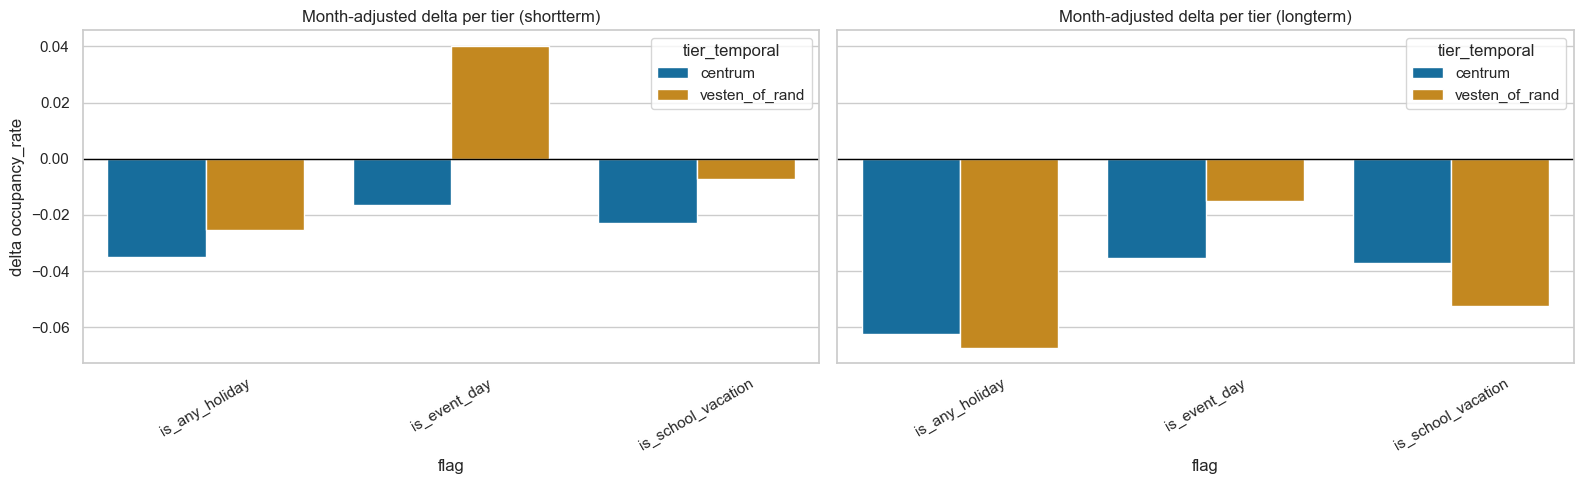

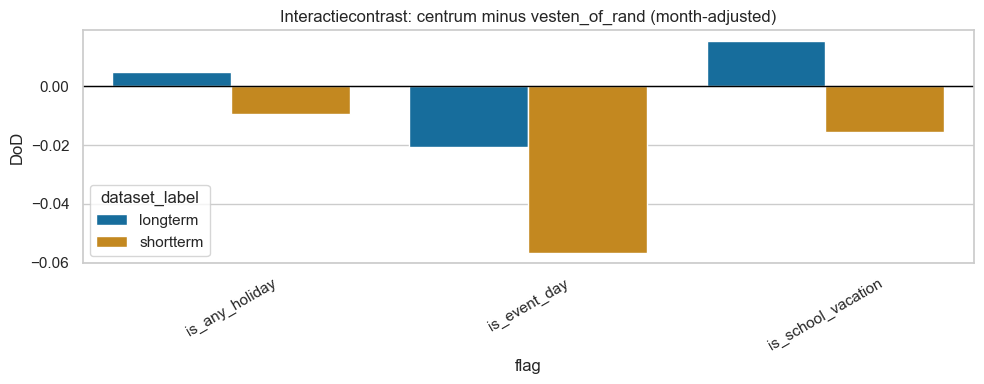

In [5]:
# Visualisaties voor tier-interacties
plot_flags = ["is_event_day", "is_any_holiday", "is_school_vacation"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, ds_label in zip(axes, ["shortterm", "longterm"]):
    sub = tier_binary_df.loc[
        (tier_binary_df["dataset_label"] == ds_label)
        & (tier_binary_df["flag_col"].isin(plot_flags))
    ].copy()

    sns.barplot(
        data=sub,
        x="flag_col",
        y="month_adjusted_delta",
        hue="tier_temporal",
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Month-adjusted delta per tier ({ds_label})")
    ax.set_xlabel("flag")
    ax.set_ylabel("delta occupancy_rate")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sub_dod = tier_dod_df.loc[tier_dod_df["flag_col"].isin(plot_flags)]
sns.barplot(data=sub_dod, x="flag_col", y="dod_month_adjusted_centrum_minus_rand", hue="dataset_label")
plt.axhline(0, color="black", linewidth=1)
plt.title("Interactiecontrast: centrum minus vesten_of_rand (month-adjusted)")
plt.xlabel("flag")
plt.ylabel("DoD")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Tusseninterpretatie (tier-interacties)**
- `event`-effecten verschillen duidelijk per tier, maar niet altijd in de intuïtieve richting "centrum sterker"; in de huidige data is eventdelta vaak groter in `vesten_of_rand`.
- `holiday`- en `school_vacation`-effecten zijn segmentafhankelijk en voor LT soms instabiel qua teken na maandcorrectie.
- Dit ondersteunt interactietermen in Phase 3, maar niet met een uniforme prior voor alle flags.

In [6]:
# 2.2 shortterm/longterm x event/holiday binnen fair scope
st_fair = SCOPES["fair_2024_common_parkings"]["shortterm"].copy()
lt_fair = SCOPES["fair_2024_common_parkings"]["longterm"].copy()

FAIR_BINARY_FLAGS = ["is_event_day", "is_any_holiday", "is_school_vacation", "is_national_holiday", "is_other_holiday"]

stlt_event_rows = []
for flag_col in FAIR_BINARY_FLAGS:
    res = diff_in_deltas_test(st_fair, lt_fair, flag_col, min_n=30)
    res.update(
        {
            "flag_col": flag_col,
            "delta_shortterm": res["delta_a"],
            "delta_longterm": res["delta_b"],
            "delta_diff_st_minus_lt": res["delta_diff_a_minus_b"],
            "month_adjusted_delta_shortterm": month_adjusted_delta(st_fair, flag_col),
            "month_adjusted_delta_longterm": month_adjusted_delta(lt_fair, flag_col),
        }
    )
    stlt_event_rows.append(res)

stlt_event_df = pd.DataFrame(stlt_event_rows)
stlt_event_df["q_value"] = p_adjust_bh(stlt_event_df["p_value"])

cols = [
    "flag_col",
    "n_true_a", "n_false_a", "n_true_b", "n_false_b",
    "delta_shortterm", "delta_longterm", "delta_diff_st_minus_lt",
    "month_adjusted_delta_shortterm", "month_adjusted_delta_longterm",
    "z_stat", "p_value", "q_value",
]

print("ST-LT interactie op binaire drivers (fair scope)")
display(stlt_event_df[cols].round(6))


ST-LT interactie op binaire drivers (fair scope)


,flag_col,n_true_a,n_false_a,n_true_b,n_false_b,delta_shortterm,delta_longterm,delta_diff_st_minus_lt,month_adjusted_delta_shortterm,month_adjusted_delta_longterm,z_stat,p_value,q_value
0,is_event_day,14680,33129,14782,31861,0.002832,-0.052038,0.054871,0.034227,-0.025746,14.996355,0.000000,0.000000
1,is_any_holiday,3360,44449,3138,43505,0.006049,-0.023375,0.029424,-0.004501,-0.063567,4.428562,0.000009,0.000024
2,is_school_vacation,13550,34259,14195,32448,-0.048240,-0.053786,0.005546,-0.011216,-0.040036,1.540703,0.123389,0.123389
3,is_national_holiday,1632,46177,1580,45063,-0.047230,-0.061901,0.014671,-0.030421,-0.089414,1.772924,0.076241,0.095302
4,is_other_holiday,1896,45913,1702,44941,0.046305,0.017853,0.028452,-0.001926,-0.032217,3.052999,0.002266,0.003776


In [7]:
# 2.3 tier x weather en ST/LT x weather
WEATHER_VARS = ["temp_c", "precip_mm", "wind_speed_ms", "sun_duration_min", "humidity_pct"]

weather_tier_rows = []
for ds_label, df in filtered_dfs.items():
    for tier, grp in df.groupby("tier_temporal"):
        for var in WEATHER_VARS:
            res = month_centered_spearman(grp, var)
            res.update(
                {
                    "dataset_label": ds_label,
                    "tier_temporal": tier,
                    "weather_var": var,
                }
            )
            weather_tier_rows.append(res)

weather_tier_df = pd.DataFrame(weather_tier_rows)
weather_tier_df["q_value"] = p_adjust_bh(weather_tier_df["p_value"])

# Tierverschil in correlatie binnen dataset (Fisher-z)
tier_weather_diff_rows = []
for ds_label in ["shortterm", "longterm"]:
    for var in WEATHER_VARS:
        sub = weather_tier_df.loc[
            (weather_tier_df["dataset_label"] == ds_label)
            & (weather_tier_df["weather_var"] == var)
        ].set_index("tier_temporal")

        if {"centrum", "vesten_of_rand"}.issubset(sub.index):
            c = sub.loc["centrum"]
            r = sub.loc["vesten_of_rand"]
            test = fisher_z_diff(c["rho"], int(c["n"]), r["rho"], int(r["n"]))

            tier_weather_diff_rows.append(
                {
                    "dataset_label": ds_label,
                    "weather_var": var,
                    "rho_centrum": float(c["rho"]),
                    "rho_rand": float(r["rho"]),
                    "rho_diff_centrum_minus_rand": float(c["rho"] - r["rho"]),
                    "z_stat": test["z_stat"],
                    "p_value": test["p_value"],
                }
            )

tier_weather_diff_df = pd.DataFrame(tier_weather_diff_rows)
tier_weather_diff_df["q_value"] = p_adjust_bh(tier_weather_diff_df["p_value"])

# ST versus LT in fair scope
weather_stlt_rows = []
for ds_label, df in [("shortterm", st_fair), ("longterm", lt_fair)]:
    for var in WEATHER_VARS:
        res = month_centered_spearman(df, var)
        res.update({"dataset_label": ds_label, "weather_var": var})
        weather_stlt_rows.append(res)

weather_stlt_df = pd.DataFrame(weather_stlt_rows)
weather_stlt_df["q_value"] = p_adjust_bh(weather_stlt_df["p_value"])

weather_stlt_diff_rows = []
for var in WEATHER_VARS:
    st_row = weather_stlt_df.loc[(weather_stlt_df["dataset_label"] == "shortterm") & (weather_stlt_df["weather_var"] == var)].iloc[0]
    lt_row = weather_stlt_df.loc[(weather_stlt_df["dataset_label"] == "longterm") & (weather_stlt_df["weather_var"] == var)].iloc[0]

    test = fisher_z_diff(st_row["rho"], int(st_row["n"]), lt_row["rho"], int(lt_row["n"]))
    weather_stlt_diff_rows.append(
        {
            "weather_var": var,
            "rho_shortterm": float(st_row["rho"]),
            "rho_longterm": float(lt_row["rho"]),
            "rho_diff_st_minus_lt": float(st_row["rho"] - lt_row["rho"]),
            "z_stat": test["z_stat"],
            "p_value": test["p_value"],
        }
    )

weather_stlt_diff_df = pd.DataFrame(weather_stlt_diff_rows)
weather_stlt_diff_df["q_value"] = p_adjust_bh(weather_stlt_diff_df["p_value"])

weather_abs_strength_df = (
    weather_stlt_df.groupby("dataset_label", as_index=False)
    .agg(mean_abs_rho_month_centered=("rho", lambda s: float(np.nanmean(np.abs(s)))))
)

print("tier x weather (month-centered Spearman)")
display(weather_tier_df.round(6))

print("tierverschillen in weather-associatie (Fisher-z)")
display(tier_weather_diff_df.round(6))

print("ST vs LT weather-associaties (fair scope)")
display(weather_stlt_df.round(6))

print("ST-LT verschil in weather-associaties (Fisher-z)")
display(weather_stlt_diff_df.round(6))

print("Gemiddelde absolute weather-koppeling (fair scope)")
display(weather_abs_strength_df.round(6))


tier x weather (month-centered Spearman)


,n,rho,p_value,dataset_label,tier_temporal,weather_var,q_value
0,116893,0.152009,0.000000,shortterm,centrum,temp_c,0.000000
1,116893,-0.013279,0.000006,shortterm,centrum,precip_mm,0.000007
2,116893,0.094611,0.000000,shortterm,centrum,wind_speed_ms,0.000000
3,116893,0.168172,0.000000,shortterm,centrum,sun_duration_min,0.000000
4,116893,-0.205485,0.000000,shortterm,centrum,humidity_pct,0.000000
5,100544,0.112873,0.000000,shortterm,vesten_of_rand,temp_c,0.000000
6,100544,-0.002510,0.426063,shortterm,vesten_of_rand,precip_mm,0.448487
7,100544,0.106996,0.000000,shortterm,vesten_of_rand,wind_speed_ms,0.000000
8,100544,0.148370,0.000000,shortterm,vesten_of_rand,sun_duration_min,0.000000
9,100544,-0.157240,0.000000,shortterm,vesten_of_rand,humidity_pct,0.000000


tierverschillen in weather-associatie (Fisher-z)


,dataset_label,weather_var,rho_centrum,rho_rand,rho_diff_centrum_minus_rand,z_stat,p_value,q_value
0,shortterm,temp_c,0.152009,0.112873,0.039136,9.262391,0.000000,0.000000
1,shortterm,precip_mm,-0.013279,-0.002510,-0.010769,-2.503826,0.012286,0.013651
2,shortterm,wind_speed_ms,0.094611,0.106996,-0.012386,-2.909118,0.003625,0.004531
3,shortterm,sun_duration_min,0.168172,0.148370,0.019801,4.722025,0.000002,0.000003
4,shortterm,humidity_pct,-0.205485,-0.157240,-0.048245,-11.600403,0.000000,0.000000
5,longterm,temp_c,0.118792,0.015334,0.103459,11.174327,0.000000,0.000000
6,longterm,precip_mm,0.001424,0.011611,-0.010187,-1.094360,0.273797,0.273797
7,longterm,wind_speed_ms,0.120729,0.038210,0.082519,8.926114,0.000000,0.000000
8,longterm,sun_duration_min,0.154187,0.036880,0.117306,12.732850,0.000000,0.000000
9,longterm,humidity_pct,-0.170285,-0.036794,-0.133491,-14.518318,0.000000,0.000000


ST vs LT weather-associaties (fair scope)


,n,rho,p_value,dataset_label,weather_var,q_value
0,47809,0.160602,0.000000,shortterm,temp_c,0.000000
1,47809,-0.018116,0.000075,shortterm,precip_mm,0.000083
2,47809,0.130025,0.000000,shortterm,wind_speed_ms,0.000000
3,47809,0.157980,0.000000,shortterm,sun_duration_min,0.000000
4,47809,-0.243190,0.000000,shortterm,humidity_pct,0.000000
5,46643,0.074701,0.000000,longterm,temp_c,0.000000
6,46643,-0.000019,0.996744,longterm,precip_mm,0.996744
7,46643,0.087401,0.000000,longterm,wind_speed_ms,0.000000
8,46643,0.095480,0.000000,longterm,sun_duration_min,0.000000
9,46643,-0.114220,0.000000,longterm,humidity_pct,0.000000


ST-LT verschil in weather-associaties (Fisher-z)


,weather_var,rho_shortterm,rho_longterm,rho_diff_st_minus_lt,z_stat,p_value,q_value
0,temp_c,0.160602,0.074701,0.085901,13.392718,0.000000,0.000000
1,precip_mm,-0.018116,-0.000019,-0.018097,-2.780898,0.005421,0.005421
2,wind_speed_ms,0.130025,0.087401,0.042624,6.628550,0.000000,0.000000
3,sun_duration_min,0.157980,0.095480,0.062500,9.763159,0.000000,0.000000
4,humidity_pct,-0.243190,-0.114220,-0.128971,-20.503148,0.000000,0.000000


Gemiddelde absolute weather-koppeling (fair scope)


,dataset_label,mean_abs_rho_month_centered
0,longterm,0.074364
1,shortterm,0.141983


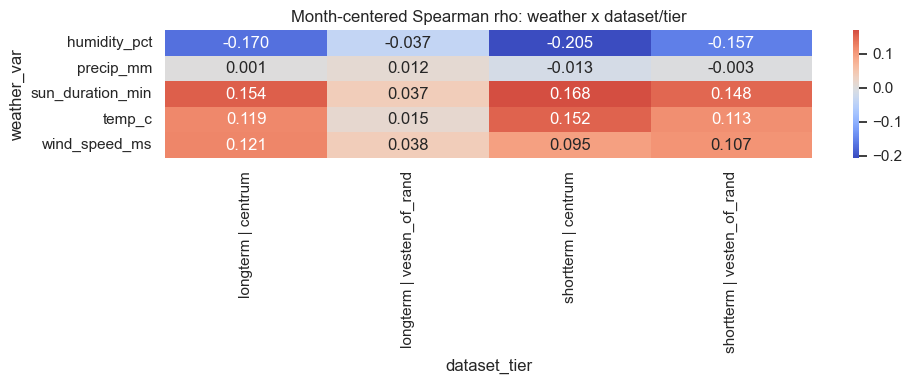

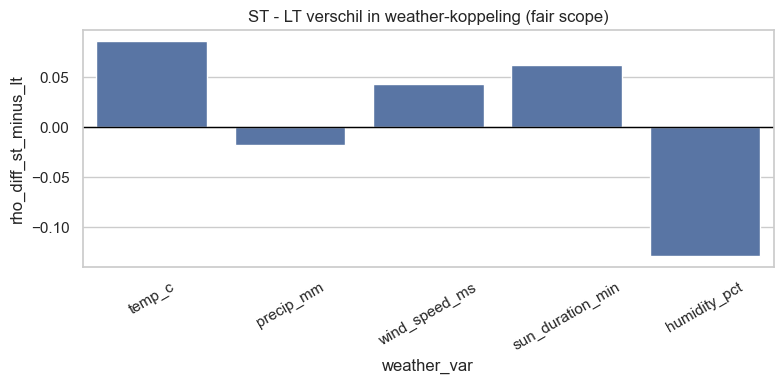

In [8]:
# Visualisaties voor weather-interacties
wt_plot = weather_tier_df.copy()
wt_plot["dataset_tier"] = wt_plot["dataset_label"] + " | " + wt_plot["tier_temporal"]
pivot_wt = wt_plot.pivot(index="weather_var", columns="dataset_tier", values="rho")

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_wt, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Month-centered Spearman rho: weather x dataset/tier")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=weather_stlt_diff_df, x="weather_var", y="rho_diff_st_minus_lt", color="#4c72b0")
plt.axhline(0, color="black", linewidth=1)
plt.title("ST - LT verschil in weather-koppeling (fair scope)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


hour x event


,n_true,n_false,mean_true,mean_false,median_true,median_false,delta_true_minus_false,cliffs_delta,u_stat,p_value,dataset_label,hour,q_value
24,610,1315,0.349792,0.387621,0.250000,0.280000,-0.037829,-0.080303,368867.5,0.004519,longterm,0,0.008034
25,601,1308,0.348874,0.381338,0.260000,0.270000,-0.032464,-0.062795,368372.0,0.027276,longterm,1,0.038507
26,601,1317,0.345050,0.377398,0.250000,0.266667,-0.032348,-0.064552,370211.5,0.023070,longterm,2,0.033556
27,602,1320,0.342659,0.375341,0.250000,0.260870,-0.032682,-0.065149,371435.0,0.021676,longterm,3,0.032515
28,604,1318,0.343218,0.379568,0.250000,0.270000,-0.036351,-0.081082,365762.5,0.004241,longterm,4,0.007829
29,611,1333,0.342675,0.379778,0.250000,0.270000,-0.037104,-0.078497,375265.0,0.005362,longterm,5,0.009192
30,622,1336,0.362688,0.415522,0.283333,0.320000,-0.052834,-0.146112,354787.0,0.000000,longterm,6,0.000000
31,622,1334,0.413710,0.488678,0.326667,0.400000,-0.074968,-0.172889,343147.0,0.000000,longterm,7,0.000000
32,609,1298,0.450103,0.526262,0.350000,0.433333,-0.076160,-0.175208,325991.5,0.000000,longterm,8,0.000000
33,620,1322,0.462806,0.523864,0.416667,0.490000,-0.061058,-0.149833,348415.5,0.000000,longterm,9,0.000000


weekday/weekend x event


,n_true,n_false,mean_true,mean_false,median_true,median_false,delta_true_minus_false,cliffs_delta,u_stat,p_value,dataset_label,is_weekend,month_adjusted_delta,q_value
0,33715,145983,0.383851,0.376723,0.320000,0.320000,0.007128,0.006207,2.476183e+09,0.075198,shortterm,False,-0.003628,0.100264
1,28086,42653,0.397149,0.389449,0.328571,0.333333,0.007699,0.006461,6.028459e+08,0.145322,shortterm,True,0.003819,0.145322
2,7638,25595,0.418042,0.461418,0.360000,0.400000,-0.043376,-0.092575,8.869831e+07,0.000000,longterm,False,-0.016504,0.000000
3,7144,6266,0.384145,0.422166,0.316667,0.350000,-0.038021,-0.094357,2.027023e+07,0.000000,longterm,True,-0.001429,0.000000


weekend-minus-weekday contrast


,dataset_label,delta_weekend_minus_weekday,month_adjusted_weekend_minus_weekday
0,shortterm,0.000571,0.007447
1,longterm,0.005355,0.015075


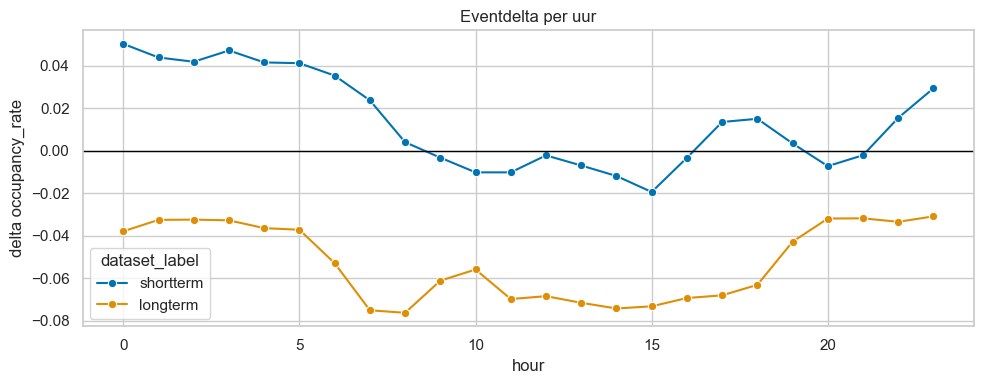

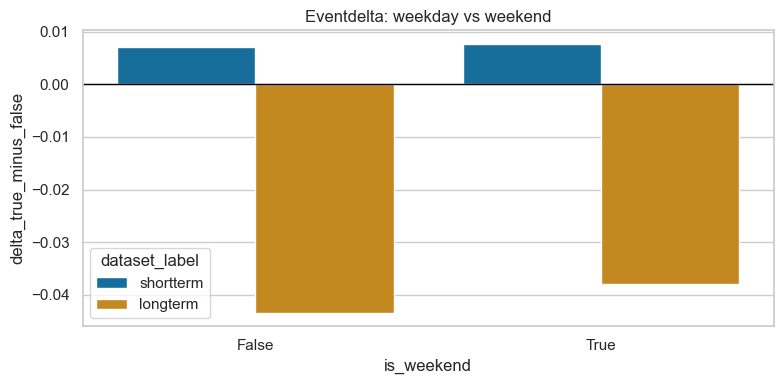

In [9]:
# 2.4 hour x event en weekday/weekend x event
hour_event_rows = []
for ds_label, df in filtered_dfs.items():
    for hour, grp in df.groupby("hour"):
        res = binary_effect_test(grp, "is_event_day", min_n=15)
        res.update(
            {
                "dataset_label": ds_label,
                "hour": int(hour),
            }
        )
        hour_event_rows.append(res)

hour_event_df = pd.DataFrame(hour_event_rows)
hour_event_df["q_value"] = p_adjust_bh(hour_event_df["p_value"])

weekend_event_rows = []
for ds_label, df in filtered_dfs.items():
    for is_weekend, grp in df.groupby("is_weekend"):
        res = binary_effect_test(grp, "is_event_day", min_n=30)
        res.update(
            {
                "dataset_label": ds_label,
                "is_weekend": bool(is_weekend),
                "month_adjusted_delta": month_adjusted_delta(grp, "is_event_day"),
            }
        )
        weekend_event_rows.append(res)

weekend_event_df = pd.DataFrame(weekend_event_rows)
weekend_event_df["q_value"] = p_adjust_bh(weekend_event_df["p_value"])

weekend_dod_rows = []
for ds_label in ["shortterm", "longterm"]:
    sub = weekend_event_df.loc[weekend_event_df["dataset_label"] == ds_label].set_index("is_weekend")
    if {True, False}.issubset(sub.index):
        weekend_dod_rows.append(
            {
                "dataset_label": ds_label,
                "delta_weekend_minus_weekday": float(sub.loc[True, "delta_true_minus_false"] - sub.loc[False, "delta_true_minus_false"]),
                "month_adjusted_weekend_minus_weekday": float(sub.loc[True, "month_adjusted_delta"] - sub.loc[False, "month_adjusted_delta"]),
            }
        )

weekend_dod_df = pd.DataFrame(weekend_dod_rows)

print("hour x event")
display(hour_event_df.sort_values(["dataset_label", "hour"]).round(6))

print("weekday/weekend x event")
display(weekend_event_df.round(6))

print("weekend-minus-weekday contrast")
display(weekend_dod_df.round(6))

# Grafieken
plt.figure(figsize=(10, 4))
sns.lineplot(data=hour_event_df, x="hour", y="delta_true_minus_false", hue="dataset_label", marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.title("Eventdelta per uur")
plt.ylabel("delta occupancy_rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=weekend_event_df, x="is_weekend", y="delta_true_minus_false", hue="dataset_label")
plt.axhline(0, color="black", linewidth=1)
plt.title("Eventdelta: weekday vs weekend")
plt.tight_layout()
plt.show()


season x weather gradients


,dataset_label,season,weather_var,q1_mean,q4_mean,delta_q4_minus_q1,n
0,shortterm,herfst,temp_c,0.333058,0.423441,0.090382,61392
1,shortterm,herfst,wind_speed_ms,0.352993,0.401138,0.048145,61392
2,shortterm,herfst,sun_duration_min,0.347704,0.468031,0.120327,61392
3,shortterm,lente,temp_c,0.332931,0.425967,0.093037,52542
4,shortterm,lente,wind_speed_ms,0.312422,0.407745,0.095324,52542
5,shortterm,lente,sun_duration_min,0.350028,0.433769,0.083741,52542
6,shortterm,winter,temp_c,0.356630,0.398233,0.041603,55762
7,shortterm,winter,wind_speed_ms,0.365937,0.401955,0.036019,55762
8,shortterm,zomer,temp_c,0.288239,0.451183,0.162945,47741
9,shortterm,zomer,wind_speed_ms,0.298618,0.443380,0.144761,47741


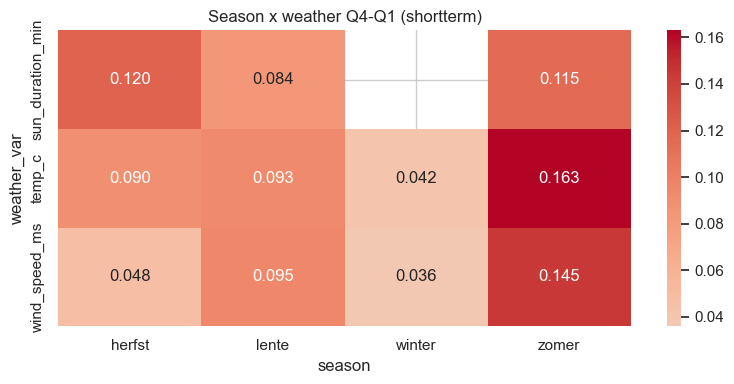

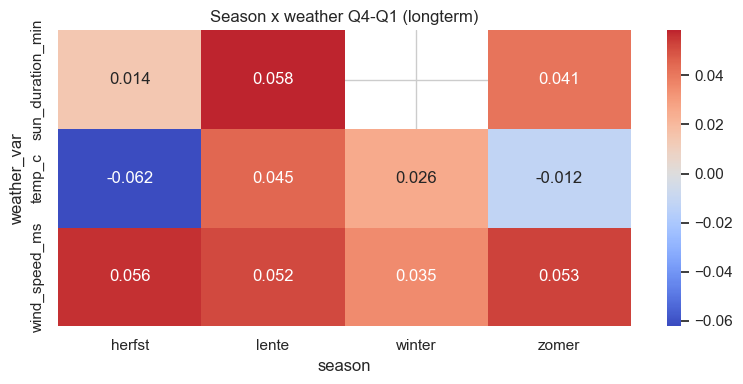

In [10]:
# 2.5 Extra interactie: season x weather (quantile-gradient Q4-Q1)
season_weather_rows = []
for ds_label, df in filtered_dfs.items():
    for season, grp in df.groupby("season"):
        for var in ["temp_c", "precip_mm", "wind_speed_ms", "sun_duration_min"]:
            d = grp[[var, "occupancy_rate"]].dropna().copy()
            if len(d) < 300:
                continue

            try:
                d["qbin"] = pd.qcut(d[var], 4, duplicates="drop")
            except ValueError:
                continue

            means = d.groupby("qbin", observed=True)["occupancy_rate"].mean().sort_index()
            if len(means) < 2:
                continue

            season_weather_rows.append(
                {
                    "dataset_label": ds_label,
                    "season": season,
                    "weather_var": var,
                    "q1_mean": float(means.iloc[0]),
                    "q4_mean": float(means.iloc[-1]),
                    "delta_q4_minus_q1": float(means.iloc[-1] - means.iloc[0]),
                    "n": int(len(d)),
                }
            )

season_weather_df = pd.DataFrame(season_weather_rows)

print("season x weather gradients")
display(season_weather_df.round(6))

for ds_label in ["shortterm", "longterm"]:
    sub = season_weather_df.loc[season_weather_df["dataset_label"] == ds_label]
    pivot = sub.pivot(index="weather_var", columns="season", values="delta_q4_minus_q1")
    plt.figure(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title(f"Season x weather Q4-Q1 ({ds_label})")
    plt.tight_layout()
    plt.show()


**Tusseninterpretatie (interactiesectie)**
- De interacties zijn reeel, maar hun teken en grootte hangen af van dataset, tier en timing; een enkel "globaal effect" is methodologisch zwak.
- `shortterm` en `longterm` reageren verschillend op externe drivers, ook wanneer we strict vergelijkbare scope gebruiken.
- Dit onderbouwt een featurestrategie met interactietermen en dataset-specifieke treatment, niet enkel main effects.

## 3. Inferentiele robuustheid en multiple-testing-bewuste rapportering
Omdat veel toetsen parallel lopen, rapporteren we zowel globale als family-wise FDR-correctie en onderscheiden we statistische detecteerbaarheid van praktische effectgrootte.

In [11]:
# 3.1 Verzamel alle uitgevoerde toetsen in 1 tabel
all_test_rows = []

for _, r in tier_binary_df.iterrows():
    all_test_rows.append(
        {
            "family": "tier_x_binary",
            "test_id": f"{r['dataset_label']}|{r['flag_col']}|{r['tier_temporal']}",
            "p_value": r["p_value"],
            "effect": r["delta_true_minus_false"],
            "effect_metric": "delta",
        }
    )

for _, r in stlt_event_df.iterrows():
    all_test_rows.append(
        {
            "family": "stlt_x_binary_fair",
            "test_id": str(r["flag_col"]),
            "p_value": r["p_value"],
            "effect": r["delta_diff_st_minus_lt"],
            "effect_metric": "delta_diff",
        }
    )

for _, r in weather_tier_df.iterrows():
    all_test_rows.append(
        {
            "family": "tier_x_weather",
            "test_id": f"{r['dataset_label']}|{r['tier_temporal']}|{r['weather_var']}",
            "p_value": r["p_value"],
            "effect": r["rho"],
            "effect_metric": "rho",
        }
    )

for _, r in tier_weather_diff_df.iterrows():
    all_test_rows.append(
        {
            "family": "tier_weather_diff",
            "test_id": f"{r['dataset_label']}|{r['weather_var']}",
            "p_value": r["p_value"],
            "effect": r["rho_diff_centrum_minus_rand"],
            "effect_metric": "rho_diff",
        }
    )

for _, r in weather_stlt_df.iterrows():
    all_test_rows.append(
        {
            "family": "stlt_x_weather_fair",
            "test_id": f"{r['dataset_label']}|{r['weather_var']}",
            "p_value": r["p_value"],
            "effect": r["rho"],
            "effect_metric": "rho",
        }
    )

for _, r in weather_stlt_diff_df.iterrows():
    all_test_rows.append(
        {
            "family": "stlt_weather_diff_fair",
            "test_id": str(r["weather_var"]),
            "p_value": r["p_value"],
            "effect": r["rho_diff_st_minus_lt"],
            "effect_metric": "rho_diff",
        }
    )

for _, r in hour_event_df.iterrows():
    all_test_rows.append(
        {
            "family": "hour_x_event",
            "test_id": f"{r['dataset_label']}|hour={int(r['hour'])}",
            "p_value": r["p_value"],
            "effect": r["delta_true_minus_false"],
            "effect_metric": "delta",
        }
    )

for _, r in weekend_event_df.iterrows():
    all_test_rows.append(
        {
            "family": "weekend_x_event",
            "test_id": f"{r['dataset_label']}|is_weekend={bool(r['is_weekend'])}",
            "p_value": r["p_value"],
            "effect": r["delta_true_minus_false"],
            "effect_metric": "delta",
        }
    )

all_tests_df = pd.DataFrame(all_test_rows)
all_tests_df["q_global"] = p_adjust_bh(all_tests_df["p_value"])
all_tests_df["q_family"] = np.nan

for family, idx in all_tests_df.groupby("family").groups.items():
    all_tests_df.loc[idx, "q_family"] = p_adjust_bh(all_tests_df.loc[idx, "p_value"]).values


def practical_threshold(metric: str) -> float:
    if metric in {"delta", "delta_diff"}:
        return 0.02
    if metric == "rho":
        return 0.10
    if metric == "rho_diff":
        return 0.05
    return 0.0


all_tests_df["abs_effect"] = all_tests_df["effect"].abs()
all_tests_df["practical_threshold"] = all_tests_df["effect_metric"].map(practical_threshold)
all_tests_df["practically_relevant"] = all_tests_df["abs_effect"] >= all_tests_df["practical_threshold"]

all_tests_df["evidence_label"] = np.select(
    [
        (all_tests_df["q_global"] < 0.05) & (all_tests_df["practically_relevant"]),
        (all_tests_df["q_global"] < 0.05) & (~all_tests_df["practically_relevant"]),
    ],
    ["robust (stat + practical)", "detectable but small"],
    default="inconclusive",
)

test_summary_df = (
    all_tests_df.groupby("family", as_index=False)
    .agg(
        n_tests=("test_id", "count"),
        n_q_global_lt_005=("q_global", lambda s: int((s < 0.05).sum())),
        n_q_family_lt_005=("q_family", lambda s: int((s < 0.05).sum())),
        n_practically_relevant=("practically_relevant", lambda s: int(s.sum())),
        n_robust=("evidence_label", lambda s: int((s == "robust (stat + practical)").sum())),
    )
    .sort_values("family")
)

robust_tests_df = all_tests_df.loc[all_tests_df["evidence_label"] == "robust (stat + practical)"]
robust_tests_df = robust_tests_df.sort_values("abs_effect", ascending=False)

print("Multiple-testing overzicht")
display(test_summary_df)

print("Top robuuste effecten")
display(robust_tests_df.head(40).round(6))


Multiple-testing overzicht


,family,n_tests,n_q_global_lt_005,n_q_family_lt_005,n_practically_relevant,n_robust
0,hour_x_event,48,34,34,33,33
1,stlt_weather_diff_fair,5,5,5,3,3
2,stlt_x_binary_fair,5,3,3,3,3
3,stlt_x_weather_fair,10,9,9,5,5
4,tier_weather_diff,10,9,9,4,4
5,tier_x_binary,20,18,18,13,13
6,tier_x_weather,20,17,17,11,11
7,weekend_x_event,4,2,2,2,2


Top robuuste effecten


,family,test_id,p_value,effect,effect_metric,q_global,q_family,abs_effect,practical_threshold,practically_relevant,evidence_label
59,stlt_x_weather_fair,shortterm|humidity_pct,0.000000,-0.243190,rho,0.000000,0.000000,0.243190,0.10,True,robust (stat + practical)
29,tier_x_weather,shortterm|centrum|humidity_pct,0.000000,-0.205485,rho,0.000000,0.000000,0.205485,0.10,True,robust (stat + practical)
39,tier_x_weather,longterm|centrum|humidity_pct,0.000000,-0.170285,rho,0.000000,0.000000,0.170285,0.10,True,robust (stat + practical)
28,tier_x_weather,shortterm|centrum|sun_duration_min,0.000000,0.168172,rho,0.000000,0.000000,0.168172,0.10,True,robust (stat + practical)
55,stlt_x_weather_fair,shortterm|temp_c,0.000000,0.160602,rho,0.000000,0.000000,0.160602,0.10,True,robust (stat + practical)
58,stlt_x_weather_fair,shortterm|sun_duration_min,0.000000,0.157980,rho,0.000000,0.000000,0.157980,0.10,True,robust (stat + practical)
34,tier_x_weather,shortterm|vesten_of_rand|humidity_pct,0.000000,-0.157240,rho,0.000000,0.000000,0.157240,0.10,True,robust (stat + practical)
38,tier_x_weather,longterm|centrum|sun_duration_min,0.000000,0.154187,rho,0.000000,0.000000,0.154187,0.10,True,robust (stat + practical)
25,tier_x_weather,shortterm|centrum|temp_c,0.000000,0.152009,rho,0.000000,0.000000,0.152009,0.10,True,robust (stat + practical)
33,tier_x_weather,shortterm|vesten_of_rand|sun_duration_min,0.000000,0.148370,rho,0.000000,0.000000,0.148370,0.10,True,robust (stat + practical)


De toetsensamenvatting toont dat veel signalen statistisch detecteerbaar zijn, maar slechts een subset ook praktisch relevant is. Voor Phase 3 moeten we dus niet maximaliseren op "significant", maar op robuuste effecten met stabiele richting over segmenten.

## 4. Formele hypothesetabel (thesis-waardig)
Onderstaande tabel vertaalt de interactie-uitkomsten naar expliciete hypothesebeoordeling met directe implicaties voor feature engineering.

In [12]:
def fmt(x: float, digits: int = 3) -> str:
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return "na"
    return f"{x:.{digits}f}"


def one_value(df: pd.DataFrame, mask: pd.Series, col: str) -> float:
    sub = df.loc[mask, col]
    if sub.empty:
        return np.nan
    return float(sub.iloc[0])


# Kernindicatoren voor hypothesetabel
st_event_dod = one_value(
    tier_dod_df,
    (tier_dod_df["dataset_label"] == "shortterm") & (tier_dod_df["flag_col"] == "is_event_day"),
    "dod_month_adjusted_centrum_minus_rand",
)
lt_event_dod = one_value(
    tier_dod_df,
    (tier_dod_df["dataset_label"] == "longterm") & (tier_dod_df["flag_col"] == "is_event_day"),
    "dod_month_adjusted_centrum_minus_rand",
)

holiday_dod_st = one_value(
    tier_dod_df,
    (tier_dod_df["dataset_label"] == "shortterm") & (tier_dod_df["flag_col"] == "is_any_holiday"),
    "dod_month_adjusted_centrum_minus_rand",
)
holiday_dod_lt = one_value(
    tier_dod_df,
    (tier_dod_df["dataset_label"] == "longterm") & (tier_dod_df["flag_col"] == "is_any_holiday"),
    "dod_month_adjusted_centrum_minus_rand",
)

stlt_event_diff = one_value(
    stlt_event_df,
    stlt_event_df["flag_col"] == "is_event_day",
    "delta_diff_st_minus_lt",
)
stlt_event_q = one_value(
    stlt_event_df,
    stlt_event_df["flag_col"] == "is_event_day",
    "q_value",
)

stlt_holiday_diff = one_value(
    stlt_event_df,
    stlt_event_df["flag_col"] == "is_any_holiday",
    "delta_diff_st_minus_lt",
)
stlt_schoolvac_diff = one_value(
    stlt_event_df,
    stlt_event_df["flag_col"] == "is_school_vacation",
    "delta_diff_st_minus_lt",
)
stlt_schoolvac_q = one_value(
    stlt_event_df,
    stlt_event_df["flag_col"] == "is_school_vacation",
    "q_value",
)

st_weather_strength = one_value(
    weather_abs_strength_df,
    weather_abs_strength_df["dataset_label"] == "shortterm",
    "mean_abs_rho_month_centered",
)
lt_weather_strength = one_value(
    weather_abs_strength_df,
    weather_abs_strength_df["dataset_label"] == "longterm",
    "mean_abs_rho_month_centered",
)

hour_range_st = float(
    hour_event_df.loc[hour_event_df["dataset_label"] == "shortterm", "delta_true_minus_false"].max()
    - hour_event_df.loc[hour_event_df["dataset_label"] == "shortterm", "delta_true_minus_false"].min()
)
hour_range_lt = float(
    hour_event_df.loc[hour_event_df["dataset_label"] == "longterm", "delta_true_minus_false"].max()
    - hour_event_df.loc[hour_event_df["dataset_label"] == "longterm", "delta_true_minus_false"].min()
)

weekend_contrast_st = one_value(
    weekend_dod_df,
    weekend_dod_df["dataset_label"] == "shortterm",
    "month_adjusted_weekend_minus_weekday",
)
weekend_contrast_lt = one_value(
    weekend_dod_df,
    weekend_dod_df["dataset_label"] == "longterm",
    "month_adjusted_weekend_minus_weekday",
)

temp_season_st = season_weather_df.loc[
    (season_weather_df["dataset_label"] == "shortterm")
    & (season_weather_df["weather_var"] == "temp_c"),
    "delta_q4_minus_q1",
]
temp_season_lt = season_weather_df.loc[
    (season_weather_df["dataset_label"] == "longterm")
    & (season_weather_df["weather_var"] == "temp_c"),
    "delta_q4_minus_q1",
]

temp_sign_switch_st = int((temp_season_st > 0).sum() > 0 and (temp_season_st < 0).sum() > 0)
temp_sign_switch_lt = int((temp_season_lt > 0).sum() > 0 and (temp_season_lt < 0).sum() > 0)

hypothesis_rows = [
    {
        "hypothesis_id": "H-I1",
        "hypothesis_statement": "Het verband tussen eventdagen en bezetting verschilt systematisch tussen centrum en vesten/rand.",
        "theoretical_motivation": "Ruimtelijke heterogeniteit en mogelijke verschuiving van verkeersdruk suggereren tier-specifieke eventrespons.",
        "data_indicators": f"DoD month-adjusted event: ST={fmt(st_event_dod)}, LT={fmt(lt_event_dod)}",
        "test_approach": "Mann-Whitney per tier + month-adjusted delta + centrum-minus-rand contrast.",
        "conclusion": "supported",
        "nuance_limitation": "Richting is niet uniform 'centrum sterker'; in deze data is eventeffect vaak groter in vesten/rand.",
        "feature_engineering_implication": "Voeg interactieterm event x tier toe en laat model de richting data-gedreven leren.",
    },
    {
        "hypothesis_id": "H-I2",
        "hypothesis_statement": "Holidayeffecten verschillen tussen tiers, maar minder robuust dan eventeffecten.",
        "theoretical_motivation": "Vakantie- en feestdagmobiliteit kan centrum/rand verschillend raken, maar met sterk kalendergebonden confounding.",
        "data_indicators": f"DoD month-adjusted holiday: ST={fmt(holiday_dod_st)}, LT={fmt(holiday_dod_lt)}",
        "test_approach": "Zelfde non-parametrische aanpak als H-I1, met focus op holiday flags.",
        "conclusion": "partially supported",
        "nuance_limitation": "Teken en grootte zijn gevoeliger voor maandcorrectie en datasetkeuze.",
        "feature_engineering_implication": "Behoud holiday x tier als kandidaatfeature, maar met sterke regularisatie en stabiliteitscheck.",
    },
    {
        "hypothesis_id": "H-I3",
        "hypothesis_statement": "Weather-occupancy associaties verschillen tussen tiers.",
        "theoretical_motivation": "Ruimtelijke context kan de gevoeligheid aan weer wijzigen via tripdoel, verblijfsduur en substitutiegedrag.",
        "data_indicators": "Month-centered rho en Fisher-z tierverschillen per weathervariabele.",
        "test_approach": "Spearman binnen tier + Fisher-z voor correlatieverschillen + FDR.",
        "conclusion": "supported",
        "nuance_limitation": "Associaties zijn descriptief en niet causaal; grootte varieert per driver.",
        "feature_engineering_implication": "Gebruik weather x tier interacties, liefst met niet-lineaire weathertransformatie.",
    },
    {
        "hypothesis_id": "H-I4",
        "hypothesis_statement": "Shortterm en longterm reageren verschillend op event- en holidaydrivers in fair scope.",
        "theoretical_motivation": "Verschillende gebruiksregimes (korte versus lange verblijfsduur) impliceren andere gevoeligheid voor exogene shocks.",
        "data_indicators": f"Delta_diff ST-LT: event={fmt(stlt_event_diff)}, holiday={fmt(stlt_holiday_diff)}, schoolvac={fmt(stlt_schoolvac_diff)}; q(event)={fmt(stlt_event_q)}, q(schoolvac)={fmt(stlt_schoolvac_q)}",
        "test_approach": "Diff-in-deltas z-test op ST versus LT binnen 2024 common-parkings scope + FDR.",
        "conclusion": "partially supported",
        "nuance_limitation": "Event en holiday verschillen zijn duidelijk, school-vacation is minder overtuigend.",
        "feature_engineering_implication": "Behoud dataset-specifieke interacties; geen harde parameter-sharing voor alle calendar/eventdrivers.",
    },
    {
        "hypothesis_id": "H-I5",
        "hypothesis_statement": "Weathergevoeligheid is gemiddeld sterker in shortterm dan in longterm.",
        "theoretical_motivation": "Shortterm wordt plausibel sneller beinvloed door korte-termijnmobiliteit en weersschommelingen.",
        "data_indicators": f"Mean |rho| month-centered fair scope: ST={fmt(st_weather_strength)}, LT={fmt(lt_weather_strength)}",
        "test_approach": "Month-centered Spearman per dataset + Fisher-z per variabele + aggregatie van |rho|.",
        "conclusion": "supported",
        "nuance_limitation": "Niet elke weatherdriver volgt hetzelfde patroon; driver-specifieke modellering blijft nodig.",
        "feature_engineering_implication": "Gebruik sterkere weatherfeature-set voor ST; compactere weatherlaag voor LT-robustness track.",
    },
    {
        "hypothesis_id": "H-I6",
        "hypothesis_statement": "Eventeffecten zijn tijdafhankelijk binnen de dag (hour x event).",
        "theoretical_motivation": "Eventmobiliteit heeft een temporeel profiel (aanloop, piek, afbouw) i.p.v. een constante dagshift.",
        "data_indicators": f"Range eventdelta per uur: ST={fmt(hour_range_st)}, LT={fmt(hour_range_lt)}",
        "test_approach": "Uur-specifieke binaire effecttests met non-parametrische toets en FDR-correctie.",
        "conclusion": "supported",
        "nuance_limitation": "Uurprofiel kan deels samenhangen met eventtypecompositie per dataset.",
        "feature_engineering_implication": "Voeg interacties toe zoals event x hour (of event x time-bins).",
    },
    {
        "hypothesis_id": "H-I7",
        "hypothesis_statement": "Eventeffecten verschillen duidelijk tussen weekdagen en weekend.",
        "theoretical_motivation": "Weekstructuur en vrijetijdsprofielen suggereren potentiele daytype-modulatie.",
        "data_indicators": f"Weekend-minus-weekday month-adjusted contrast: ST={fmt(weekend_contrast_st)}, LT={fmt(weekend_contrast_lt)}",
        "test_approach": "Binaire effecttests per daytype en contrastanalyse.",
        "conclusion": "not supported / inconclusive",
        "nuance_limitation": "In deze data is extra modulatie door daytype klein t.o.v. hoofd- en uurinteractie.",
        "feature_engineering_implication": "Weekday/weekend x event enkel opnemen indien modelselectie expliciet winst toont.",
    },
    {
        "hypothesis_id": "H-I8",
        "hypothesis_statement": "Weather-effecten zijn seizoensafhankelijk (season x weather).",
        "theoretical_motivation": "Seizoenscontext verandert de interpretatie van identieke weatherniveaus.",
        "data_indicators": f"Temp sign-switch over seizoenen: ST={temp_sign_switch_st}, LT={temp_sign_switch_lt}",
        "test_approach": "Binnen-seizoen quantile-gradients (Q4-Q1) per weathervariabele.",
        "conclusion": "partially supported",
        "nuance_limitation": "Sterker en consistenter in ST; LT-signaal is zwakker en onstabieler.",
        "feature_engineering_implication": "Gebruik weather x season interacties primair in ST-pipeline.",
    },
    {
        "hypothesis_id": "H-I9",
        "hypothesis_statement": "Voor thesis-hoofdmodellering is ST de primaire analytische basis, LT secundair als robustness-track.",
        "theoretical_motivation": "Representativiteit en temporele coverage bepalen de betrouwbaarheid van generaliseerbare patroonextractie.",
        "data_indicators": "LT bevat enkel 2024 en minder parkings; eda_05 toonde regimeverschillen en beperktere overdraagbaarheid.",
        "test_approach": "Synthese van coverage-audit, ST-LT fairness-analyses en interactiestabiliteit.",
        "conclusion": "supported",
        "nuance_limitation": "LT hoeft niet weggegooid te worden, maar mag niet de primaire inferentiebasis zijn.",
        "feature_engineering_implication": "Ontwerp Phase 3 rond ST; gebruik LT voor secundaire stress-test en transfer-checks.",
    },
]

hypothesis_table_df = pd.DataFrame(hypothesis_rows)
display(hypothesis_table_df)


,hypothesis_id,hypothesis_statement,theoretical_motivation,data_indicators,test_approach,conclusion,nuance_limitation,feature_engineering_implication
0,H-I1,Het verband tussen eventdagen en bezetting ver...,Ruimtelijke heterogeniteit en mogelijke versch...,"DoD month-adjusted event: ST=-0.057, LT=-0.021",Mann-Whitney per tier + month-adjusted delta +...,supported,Richting is niet uniform 'centrum sterker'; in...,Voeg interactieterm event x tier toe en laat m...
1,H-I2,"Holidayeffecten verschillen tussen tiers, maar...",Vakantie- en feestdagmobiliteit kan centrum/ra...,"DoD month-adjusted holiday: ST=-0.009, LT=0.005","Zelfde non-parametrische aanpak als H-I1, met ...",partially supported,Teken en grootte zijn gevoeliger voor maandcor...,"Behoud holiday x tier als kandidaatfeature, ma..."
2,H-I3,Weather-occupancy associaties verschillen tuss...,Ruimtelijke context kan de gevoeligheid aan we...,Month-centered rho en Fisher-z tierverschillen...,Spearman binnen tier + Fisher-z voor correlati...,supported,Associaties zijn descriptief en niet causaal; ...,"Gebruik weather x tier interacties, liefst met..."
3,H-I4,Shortterm en longterm reageren verschillend op...,Verschillende gebruiksregimes (korte versus la...,"Delta_diff ST-LT: event=0.055, holiday=0.029, ...",Diff-in-deltas z-test op ST versus LT binnen 2...,partially supported,"Event en holiday verschillen zijn duidelijk, s...",Behoud dataset-specifieke interacties; geen ha...
4,H-I5,Weathergevoeligheid is gemiddeld sterker in sh...,Shortterm wordt plausibel sneller beinvloed do...,Mean |rho| month-centered fair scope: ST=0.142...,Month-centered Spearman per dataset + Fisher-z...,supported,Niet elke weatherdriver volgt hetzelfde patroo...,Gebruik sterkere weatherfeature-set voor ST; c...
5,H-I6,Eventeffecten zijn tijdafhankelijk binnen de d...,Eventmobiliteit heeft een temporeel profiel (a...,"Range eventdelta per uur: ST=0.070, LT=0.045",Uur-specifieke binaire effecttests met non-par...,supported,Uurprofiel kan deels samenhangen met eventtype...,Voeg interacties toe zoals event x hour (of ev...
6,H-I7,Eventeffecten verschillen duidelijk tussen wee...,Weekstructuur en vrijetijdsprofielen suggerere...,Weekend-minus-weekday month-adjusted contrast:...,Binaire effecttests per daytype en contrastana...,not supported / inconclusive,In deze data is extra modulatie door daytype k...,Weekday/weekend x event enkel opnemen indien m...
7,H-I8,Weather-effecten zijn seizoensafhankelijk (sea...,Seizoenscontext verandert de interpretatie van...,"Temp sign-switch over seizoenen: ST=0, LT=1",Binnen-seizoen quantile-gradients (Q4-Q1) per ...,partially supported,Sterker en consistenter in ST; LT-signaal is z...,Gebruik weather x season interacties primair i...
8,H-I9,Voor thesis-hoofdmodellering is ST de primaire...,Representativiteit en temporele coverage bepal...,LT bevat enkel 2024 en minder parkings; eda_05...,"Synthese van coverage-audit, ST-LT fairness-an...",supported,"LT hoeft niet weggegooid te worden, maar mag n...",Ontwerp Phase 3 rond ST; gebruik LT voor secun...


## 5. Academische synthese (thesisstijl)
De gecombineerde EDA-evidentie bevestigt dat het parkeersysteem niet adequaat beschreven wordt door univariate globale patronen. De structuur is interactief: tijd, ruimte en externe drivers moduleren elkaar en doen dit bovendien dataset-specifiek.

### Sterk ondersteund
- `H-I1`, `H-I3`, `H-I5`, `H-I6`, `H-I9`.
- Vooral de combinatie van tier-heterogeniteit, time-structuur en ST-LT regimeverschil is consistent over meerdere notebooks.

### Partieel ondersteund
- `H-I2`, `H-I4`, `H-I8`.
- Er zijn duidelijke signalen, maar stabiliteit hangt af van driver, segment en correctieniveau (bv. month-adjustment/fair scope).

### Niet overtuigend ondersteund
- `H-I7`.
- Daytype (`weekday/weekend`) voegt hier minder toe dan uur- en tiersegmentatie.

### Extra voorzichtigheid door zwakkere data/literatuurbasis
- LT-resultaten vragen extra terughoudendheid: beperkte tijdsdekking (enkele jaargang) en lagere representativiteit.
- Bij zeer grote steekproeven zijn p-values onvoldoende; effectgrootte en stabiliteit over segmenten moeten leidend blijven.
- Alle resultaten blijven descriptief; causale taal is niet verantwoord in deze EDA-fase.

## EDA decisions that must carry forward into Phase 3
1. Gebruik `shortterm` als primaire modeltrack; behandel `longterm` als secundaire robustness/transfer-track.
2. Houd het quality-filter uit `eda_00` als standaard voor inferentierelevante analyses.
3. Behoud een fairness-scope (`2024 + common parkings`) voor elke expliciete ST-LT vergelijking.
4. Modelleer interacties expliciet: minimaal `event x tier`, `weather x season`, `event x hour`.
5. Gebruik niet-lineaire weatherrepresentaties (bins/splines) in plaats van enkel lineaire termen.
6. Rapporteer consequent effectgrootte naast p-waarden; gebruik FDR-correctie bij families van toetsen.
7. Prioriteer features met zowel statistische als praktische relevantie.
8. Vermijd overmatige feature-sharing tussen ST en LT; laat dataset-specifieke parameterisatie toe.
9. Neem coverage- en representativiteitsdiagnostiek op als vaste modelgovernancecheck.
10. Behoud een sensitiviteitslaag waarin zwakkere of instabiele interacties optioneel uitgeschakeld kunnen worden.

## Key findings
1. Interacties zijn centraal, niet marginaal: tier, tijd en externe drivers moduleren occupancy gelijktijdig.
2. ST en LT vertonen verschillende responsstructuren, ook in een strikte fair scope.
3. Veel effecten zijn statistisch detecteerbaar, maar slechts een subset is praktisch groot genoeg voor robuuste featurekeuzes.
4. De EDA-synthese ondersteunt een ST-gedreven Phase 3 met interactie-rijke, segmentbewuste feature engineering.

## Implications for feature engineering
1. Bouw een interaction-first feature set met gecontroleerde complexiteit (regularisatie + stabiliteitschecks).
2. Maak weatherfeatures seizoensafhankelijk en bij voorkeur niet-lineair gecodeerd.
3. Modelleer eventimpact tijdsafhankelijk (hour/event windows) en ruimtelijk gedifferentieerd (tier/parking).
4. Gebruik LT niet als primaire trainingsbasis, maar als aanvullende validatielaag voor overdraagbaarheid.
5. Veranker multiple-testing en effect-size rapportage in de feature-selectieprocedure.

## Open questions for next notebook
1. Welke interactiefeatures blijven stabiel in out-of-time validatie binnen ST?
2. Welke minimale LT-featureset is nog zinvol voor robustness zonder overfitting?
3. Hoeveel prestatiewinst levert interaction-first engineering boven een main-effects baseline?
4. Welke interacties zijn robuust genoeg om in explainability (Phase 4) centraal te zetten?